# ANN Model Training with TensorFlow 


## Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
import time
import itertools
import multiprocessing as mp
from collections import defaultdict
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    r2_score, mean_squared_error
)
warnings.filterwarnings('ignore')

SEP          = os.sep
random_state = 21
np.random.seed(random_state)

print('Libraries imported successfully!')


Libraries imported successfully!


## TensorFlow Setup

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

print('=' * 70)
print('TENSORFLOW & GPU CONFIGURATION')
print('=' * 70)
print(f'TensorFlow version : {tf.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'\n✓ GPU acceleration ENABLED')
        for i, g in enumerate(gpus):
            print(f'  GPU {i}: {g.name}')
        DEVICE = '/GPU:0'
    except RuntimeError as e:
        print(f'GPU setup error: {e}')
        DEVICE = '/CPU:0'
else:
    print('\n⚠  No GPU found — using CPU')
    DEVICE = '/CPU:0'

print(f'\nActive device: {DEVICE}')

# Reproducibility
tf.random.set_seed(random_state)

# Try nvidia-smi
try:
    import subprocess
    res = subprocess.run(
        ['nvidia-smi','--query-gpu=index,name,utilization.gpu,memory.used,memory.total',
         '--format=csv,noheader,nounits'],
        capture_output=True, text=True, timeout=5)
    if res.returncode == 0:
        print('\nGPU Status:')
        print('GPU | Name | Util% | MemUsed MB | MemTotal MB')
        print(res.stdout)
except Exception:
    pass

print('=' * 70)


TENSORFLOW & GPU CONFIGURATION
TensorFlow version : 2.20.0

⚠  No GPU found — using CPU

Active device: /CPU:0


## Load and Prepare Data

In [12]:
print('Loading data...')
df = pd.read_excel('PGM_CBFV_01_norm_feature.xlsx').sample(
    frac=1, random_state=random_state, ignore_index=True)

print('\nFirst 5 rows:')
display(df.head())

y_prop     = 'Mass_Change'
feat_names = ['avg_number_of_valence_electrons', 'EN_Pauling', 'r_asym',
              'H_chem', 'H_el', 'Time', 'Coh_E']

X = np.array(df[feat_names], dtype=np.float32)
Y = np.array(df[y_prop],     dtype=np.float32)

print(f'\nX shape : {X.shape}')
print(f'Y shape : {Y.shape}')
print(f'Features: {feat_names}')
print(f'Target  : {y_prop}')


Loading data...

First 5 rows:


,alloy_name,Mass_Change,r_asym,avg_number_of_valence_electrons,Coh_E,EN_Pauling,H_chem,H_el,Time,Temp
0,Ni48Al22Pt30,1.004987,1.000000,0.936073,1.000000,0.847969,0.522028,0.921596,0.389386,1
1,Ni41Al50Rh9,0.891721,0.892139,0.000000,0.224837,0.684098,0.967581,0.957359,0.651645,1
2,Ni48Al22Pt30,1.066581,1.000000,0.936073,1.000000,0.847969,0.522028,0.921596,0.441437,1
3,Ni41Al50Rh9,0.266378,0.892139,0.000000,0.224837,0.684098,0.967581,0.957359,0.032898,1
4,Ni35Al50Pt15,0.467160,0.794827,0.041096,0.344603,1.000000,0.000000,0.891334,0.179177,1



X shape : (4343, 7)
Y shape : (4343,)
Features: ['avg_number_of_valence_electrons', 'EN_Pauling', 'r_asym', 'H_chem', 'H_el', 'Time', 'Coh_E']
Target  : Mass_Change


## Create Output Directories

In [13]:
ALGO        = 'ann_tf'
MODEL_DIR   = 'trained_mod_CBFV_ann_tf'
PARITY_DIR  = 'ann_tf_parity_plots'
RESULTS_DIR = 'ann_tf_results'

for d in [MODEL_DIR, PARITY_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f'✓ Created: {d}')

print('\nAll directories ready!')


✓ Created: trained_mod_CBFV_ann_tf
✓ Created: ann_tf_parity_plots
✓ Created: ann_tf_results

All directories ready!


## Define Keras Model Builder

In [14]:
def build_keras_model(input_dim, hidden_layers, activation,
                       dropout_rate, l2_reg, learning_rate,
                       batch_norm):
    """
    Build a fully-connected Keras regression model.

    Parameters
    ----------
    input_dim     : int   – number of input features
    hidden_layers : tuple – neurons per hidden layer, e.g. (256, 128, 64)
    activation    : str   – 'relu', 'tanh', 'elu', 'swish'
    dropout_rate  : float – dropout probability after each hidden layer (0 = off)
    l2_reg        : float – L2 weight-decay coefficient
    learning_rate : float – Adam learning rate
    batch_norm    : bool  – whether to add BatchNormalization after each dense layer
    """
    with tf.device(DEVICE):
        inp = keras.Input(shape=(input_dim,), name='features')
        x   = inp

        for i, units in enumerate(hidden_layers):
            x = layers.Dense(
                units,
                activation=None,
                kernel_regularizer=regularizers.l2(l2_reg),
                name=f'dense_{i+1}'
            )(x)
            if batch_norm:
                x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
            x = layers.Activation(activation, name=f'act_{i+1}')(x)
            if dropout_rate > 0:
                x = layers.Dropout(dropout_rate, name=f'drop_{i+1}')(x)

        out = layers.Dense(1, name='output')(x)

        model = keras.Model(inputs=inp, outputs=out)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )
    return model


# Quick sanity check
test_model = build_keras_model(
    input_dim=len(feat_names),
    hidden_layers=(128, 64),
    activation='relu',
    dropout_rate=0.1,
    l2_reg=1e-4,
    learning_rate=1e-3,
    batch_norm=True
)
test_model.summary()
del test_model
print('\nModel builder verified!')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 384 (1.50 KB)


Model builder verified!


## Define Hyperparameter Grid

In [19]:
param_grid = {
    'hidden_layers' : [
        (128, 64),
        (128, 64, 32),
        (128, 64, 32, 16),
        (56, 48, 32, 24, 8),
        (56, 48, 40, 32, 24, 16, 8),
    ],
    'activation'    : ['relu', 'tanh', 'elu'],
    'dropout_rate'  : [0.0, 0.1, 0.2],
    'l2_reg'        : [0.0, 1e-5, 1e-4],
    'alpha':         [1e-5, 1e-4, 1e-3, 1e-2], 
    'learning_rate' : [1e-4,  5e-3],
    'batch_norm'    : [True],
    'batch_size'    : [128, 256],
    'beta_1':        [0.85, 0.9, 0.95],
    'beta_2':        [0.99, 0.999],
    'max_iter': [500, 1000, 2000],  
}

}

# Training constants (not part of architecture grid)
PATIENCE      = 20    # early stopping patience
VAL_FRACTION  = 0.1   # fraction of training data used for early-stopping
VERBOSE_FIT   = 0     # 0 = silent, 1 = progress bar

print('=' * 70)
print('HYPERPARAMETER GRID – ANN (TensorFlow/Keras)')
print('=' * 70)
for k, v in param_grid.items():
    print(f'  {k}: {v}')

# Total combinations
total = 1
for v in param_grid.values(): total *= len(v)
print(f'\nTotal architecture combinations : {total:,}')
print(f'Early-stopping patience         : {PATIENCE}')
print(f'Note: Grid is evaluated with 3-fold CV to find top 5 sets.')
print('      Full 5-fold CV is then run on those top sets.')


HYPERPARAMETER GRID – ANN (TensorFlow/Keras)
  hidden_layers: [(128, 64), (128, 64, 32), (128, 64, 32, 16), (56, 48, 40, 32, 24, 16, 8)]
  activation: ['relu', 'tanh', 'elu']
  dropout_rate: [0.0, 0.1, 0.2]
  l2_reg: [0.0, 1e-05, 0.0001]
  learning_rate: [0.0001, 0.005]
  batch_norm: [True]
  batch_size: [128, 256]

Total architecture combinations : 432
MAX_EPOCHS per fit              : 300
Early-stopping patience         : 20
Note: Grid is evaluated with 3-fold CV to find top 5 sets.
      Full 5-fold CV is then run on those top sets.


## Manual Grid Search (3-Fold CV)

In [20]:
print('=' * 70)
print('STARTING GRID SEARCH – ANN (TensorFlow/Keras)')
print('=' * 70)

# Build list of all parameter combinations
keys   = list(param_grid.keys())
values = list(param_grid.values())
all_combinations = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
total_combos = len(all_combinations)
print(f'Total combinations : {total_combos:,}')
print(f'CV folds (grid)    : 3')
print(f'Total fits         : {total_combos * 3:,}')
print()

kf_gs = KFold(n_splits=3, shuffle=True, random_state=random_state)
gs_results = []
gs_start   = time.time()

for combo_idx, params in enumerate(all_combinations):
    fold_maes = []

    for tr_idx, te_idx in kf_gs.split(X):
        x_tr_raw, x_te_raw = X[tr_idx], X[te_idx]
        y_tr, y_te         = Y[tr_idx], Y[te_idx]

        # Scale per fold (no data leakage)
        gs_scaler = StandardScaler()
        x_tr = gs_scaler.fit_transform(x_tr_raw)
        x_te = gs_scaler.transform(x_te_raw)

        # Validation split from training data for early stopping
        val_size = max(1, int(len(x_tr) * VAL_FRACTION))
        x_val, y_val = x_tr[-val_size:], y_tr[-val_size:]
        x_tr_fit,y_tr_fit = x_tr[:-val_size], y_tr[:-val_size]

        model = build_keras_model(
            input_dim     = X.shape[1],
            hidden_layers = params['hidden_layers'],
            activation    = params['activation'],
            dropout_rate  = params['dropout_rate'],
            l2_reg        = params['l2_reg'],
            learning_rate = params['learning_rate'],
            batch_norm    = params['batch_norm'],
        )

        es = callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0)

        model.fit(
            x_tr_fit, y_tr_fit,
            validation_data=(x_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=params['batch_size'],
            callbacks=[es],
            verbose=VERBOSE_FIT
        )

        yp_te = model.predict(x_te, verbose=0).flatten()
        fold_maes.append(mean_absolute_error(y_te, yp_te))
        del model; keras.backend.clear_session()

    mean_mae = float(np.mean(fold_maes))
    std_mae  = float(np.std(fold_maes))
    gs_results.append({'params': params, 'mean_test_mae': mean_mae, 'std_test_mae': std_mae})

    elapsed = time.time() - gs_start
    avg_t   = elapsed / (combo_idx + 1)
    eta_sec = avg_t * (total_combos - combo_idx - 1)
    eta_str = (f'{eta_sec/3600:.1f}h' if eta_sec >= 3600
               else f'{eta_sec/60:.1f}m' if eta_sec >= 60
               else f'{eta_sec:.0f}s')
    print(f'\r  [{combo_idx+1:>5}/{total_combos}]  MAE={mean_mae:.5f}  '
          f'Elapsed={elapsed/60:.1f}m  ETA={eta_str}   ', end='', flush=True)

search_time = time.time() - gs_start
print()

cv_results_df = (
    pd.DataFrame(gs_results)
    .sort_values('mean_test_mae')
    .reset_index(drop=True)
)

print('\n' + '=' * 70)
print('GRID SEARCH COMPLETED')
print('=' * 70)
print(f'Total time : {search_time/60:.2f} minutes')
print(f'Best CV MAE: {cv_results_df.iloc[0]["mean_test_mae"]:.6f}')
print('\nBest Parameters:')
for k, v in cv_results_df.iloc[0]['params'].items():
    print(f'  {k}: {v}')


STARTING GRID SEARCH – ANN (TensorFlow/Keras)
Total combinations : 432
CV folds (grid)    : 3
Total fits         : 1,296

  [  432/432]  MAE=0.10429  Elapsed=1776.0m  ETA=0s      

GRID SEARCH COMPLETED
Total time : 1776.03 minutes
Best CV MAE: 0.032207

Best Parameters:
  hidden_layers: (128, 64, 32)
  activation: relu
  dropout_rate: 0.1
  l2_reg: 0.0
  learning_rate: 0.005
  batch_norm: True
  batch_size: 256


## Extract and Save Top Parameter Sets

In [21]:
print('=' * 70)
print('TOP 10 PARAMETER COMBINATIONS')
print('=' * 70)

top_params_df = cv_results_df.head(10)[['params','mean_test_mae','std_test_mae']].copy()
top_params_df.index = range(1, 11)
display(top_params_df)

top_params_df.to_csv(f'{RESULTS_DIR}/top_10_parameter_sets.csv')
print(f'\nSaved -> {RESULTS_DIR}/top_10_parameter_sets.csv')

cv_results_sorted = cv_results_df  # alias used in later cells


TOP 10 PARAMETER COMBINATIONS


,params,mean_test_mae,std_test_mae
1,"{'hidden_layers': (128, 64, 32), 'activation':...",0.032207,0.002411
2,"{'hidden_layers': (56, 48, 40, 32, 24, 16, 8),...",0.032946,0.004768
3,"{'hidden_layers': (128, 64, 32), 'activation':...",0.033806,0.004855
4,"{'hidden_layers': (128, 64, 32), 'activation':...",0.036084,0.001151
5,"{'hidden_layers': (128, 64, 32), 'activation':...",0.036100,0.003394
6,"{'hidden_layers': (128, 64), 'activation': 're...",0.036735,0.005035
7,"{'hidden_layers': (128, 64, 32, 16), 'activati...",0.037120,0.005518
8,"{'hidden_layers': (128, 64, 32, 16), 'activati...",0.038197,0.004141
9,"{'hidden_layers': (128, 64, 32, 16), 'activati...",0.038407,0.002483
10,"{'hidden_layers': (128, 64, 32), 'activation':...",0.038731,0.005416



Saved -> ann_tf_results/top_10_parameter_sets.csv


## K-Fold Cross-Validation for Top 5 Parameter Sets

In [22]:
print('=' * 70)
print('TESTING TOP PARAMETER SETS WITH 5-FOLD K-FOLD CV')
print('=' * 70)

top_n_sets     = 5
top_param_sets = cv_results_sorted.head(top_n_sets)['params'].tolist()
all_param_set_results = []
Kfold_val = 5

# Learning rate scheduler: cosine decay
def get_callbacks(monitor='val_loss'):
    es = callbacks.EarlyStopping(
        monitor=monitor, patience=PATIENCE,
        restore_best_weights=True, verbose=0)
    rlrop = callbacks.ReduceLROnPlateau(
        monitor=monitor, factor=0.5, patience=10,
        min_lr=1e-6, verbose=0)
    return [es, rlrop]

for set_idx, param_set in enumerate(top_param_sets, 1):
    print(f'\n{"="*70}')
    print(f'PARAMETER SET {set_idx}/{top_n_sets}')
    print(f'{"="*70}')
    for k, v in param_set.items(): print(f'  {k}: {v}')

    kf = KFold(n_splits=Kfold_val, shuffle=True, random_state=random_state)
    metrics = {k: [] for k in [
        'train_mae','test_mae','train_mse','test_mse',
        'train_rmse','test_rmse','train_mape','test_mape',
        'train_r2','test_r2','epochs_used']}
    all_predictions = {'train':[],'test':[],'y_train':[],'y_test':[]}
    k_count   = 1
    set_start = time.time()

    for tr_idx, te_idx in kf.split(X):
        x_tr_raw, x_te_raw = X[tr_idx], X[te_idx]
        y_tr, y_te         = Y[tr_idx], Y[te_idx]

        # Per-fold scaler
        fold_scaler = StandardScaler()
        x_tr = fold_scaler.fit_transform(x_tr_raw)
        x_te = fold_scaler.transform(x_te_raw)

        val_size = max(1, int(len(x_tr) * VAL_FRACTION))
        x_val,y_val     = x_tr[-val_size:], y_tr[-val_size:]
        x_tr_f,y_tr_f   = x_tr[:-val_size], y_tr[:-val_size]

        fold_start = time.time()
        model = build_keras_model(
            input_dim     = X.shape[1],
            hidden_layers = param_set['hidden_layers'],
            activation    = param_set['activation'],
            dropout_rate  = param_set['dropout_rate'],
            l2_reg        = param_set['l2_reg'],
            learning_rate = param_set['learning_rate'],
            batch_norm    = param_set['batch_norm'],
        )

        hist = model.fit(
            x_tr_f, y_tr_f,
            validation_data=(x_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=param_set['batch_size'],
            callbacks=get_callbacks(),
            verbose=VERBOSE_FIT
        )
        epochs_used = len(hist.history['loss'])
        fold_time   = time.time() - fold_start

        # Predict (use full x_tr for train metrics)
        yp_tr = model.predict(x_tr, verbose=0).flatten()
        yp_te = model.predict(x_te, verbose=0).flatten()

        all_predictions['train'].extend(yp_tr.tolist())
        all_predictions['y_train'].extend(y_tr.tolist())
        all_predictions['test'].extend(yp_te.tolist())
        all_predictions['y_test'].extend(y_te.tolist())

        tr_mse = mean_squared_error(y_tr, yp_tr)
        te_mse = mean_squared_error(y_te, yp_te)
        metrics['train_mae'].append(mean_absolute_error(y_tr, yp_tr))
        metrics['test_mae'].append(mean_absolute_error(y_te, yp_te))
        metrics['train_mse'].append(tr_mse)
        metrics['test_mse'].append(te_mse)
        metrics['train_rmse'].append(np.sqrt(tr_mse))
        metrics['test_rmse'].append(np.sqrt(te_mse))
        metrics['train_mape'].append(mean_absolute_percentage_error(y_tr, yp_tr))
        metrics['test_mape'].append(mean_absolute_percentage_error(y_te, yp_te))
        metrics['train_r2'].append(r2_score(y_tr, yp_tr))
        metrics['test_r2'].append(r2_score(y_te, yp_te))
        metrics['epochs_used'].append(epochs_used)

        # Save model + scaler
        model.save(f'{MODEL_DIR}/ann_tf-set{set_idx:02d}-K{k_count}.keras')
        pickle.dump(fold_scaler, open(
            f'{MODEL_DIR}/scaler-set{set_idx:02d}-K{k_count}.pkl', 'wb'))

        print(f'  Fold {k_count}  '
              f'MAE={metrics["test_mae"][-1]:.6f}  '
              f'R²={metrics["test_r2"][-1]:.4f}  '
              f'epochs={epochs_used}  ({fold_time:.1f}s)')
        k_count += 1
        del model; keras.backend.clear_session()

    set_time = time.time() - set_start
    print(f'\n  Completed in {set_time:.2f}s')

    set_summary = {'param_set': set_idx}
    for m in ['mae','mse','rmse','mape','r2']:
        set_summary[f'train_{m}_mean'] = np.mean(metrics[f'train_{m}'])
        set_summary[f'train_{m}_std']  = np.std(metrics[f'train_{m}'])
        set_summary[f'test_{m}_mean']  = np.mean(metrics[f'test_{m}'])
        set_summary[f'test_{m}_std']   = np.std(metrics[f'test_{m}'])
        print(f'  {m.upper():5s}: Train={np.mean(metrics[f"train_{m}"]):.6f} '
              f' Test={np.mean(metrics[f"test_{m}"]):.6f}')
    print(f'  Avg epochs : {np.mean(metrics["epochs_used"]):.1f}')
    all_param_set_results.append(set_summary)

    pd.DataFrame(metrics, index=[f'Fold_{i+1}' for i in range(Kfold_val)]).to_csv(
        f'{RESULTS_DIR}/cv_results_set{set_idx:02d}.csv')

    locals()[f'metrics_set{set_idx}']     = metrics
    locals()[f'predictions_set{set_idx}'] = all_predictions
    locals()[f'params_set{set_idx}']      = param_set

print('\n' + '=' * 70)
print('K-FOLD CV COMPLETED')
print('=' * 70)


TESTING TOP PARAMETER SETS WITH 5-FOLD K-FOLD CV

PARAMETER SET 1/5
  hidden_layers: (128, 64, 32)
  activation: relu
  dropout_rate: 0.1
  l2_reg: 0.0
  learning_rate: 0.005
  batch_norm: True
  batch_size: 256
  Fold 1  MAE=0.027183  R²=0.9926  epochs=193  (56.9s)
  Fold 2  MAE=0.030083  R²=0.9909  epochs=275  (78.0s)
  Fold 3  MAE=0.025841  R²=0.9925  epochs=186  (51.2s)
  Fold 4  MAE=0.026808  R²=0.9921  epochs=167  (103.1s)
  Fold 5  MAE=0.031829  R²=0.9893  epochs=162  (93.8s)

  Completed in 519.89s
  MAE  : Train=0.027864  Test=0.028349
  MSE  : Train=0.001482  Test=0.001557
  RMSE : Train=0.038447  Test=0.039374
  MAPE : Train=0.264696  Test=0.254402
  R2   : Train=0.991928  Test=0.991492
  Avg epochs : 196.6

PARAMETER SET 2/5
  hidden_layers: (56, 48, 40, 32, 24, 16, 8)
  activation: relu
  dropout_rate: 0.0
  l2_reg: 1e-05
  learning_rate: 0.005
  batch_norm: True
  batch_size: 256
  Fold 1  MAE=0.020016  R²=0.9954  epochs=300  (109.9s)
  Fold 2  MAE=0.022137  R²=0.9950  ep

## Generate Parity Plots for Each Parameter Set

GENERATING PARITY PLOTS


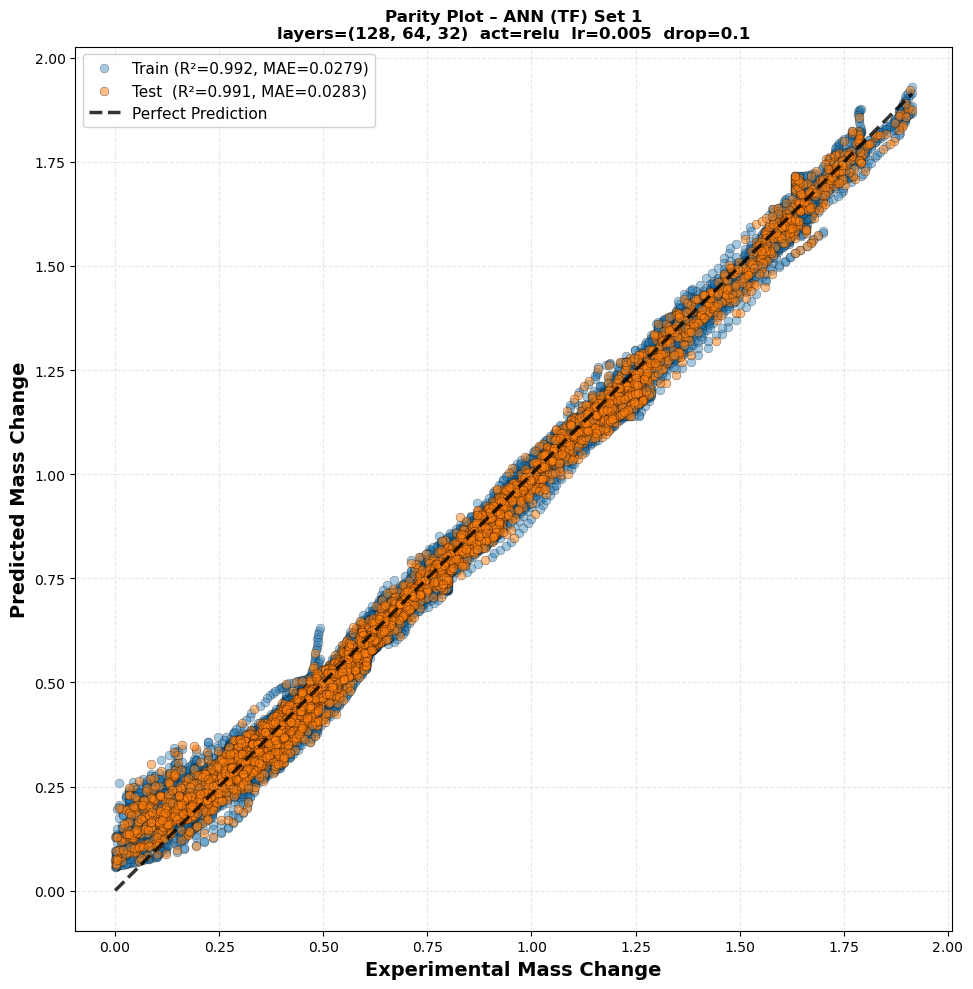

✓ Saved: ann_tf_parity_plots/parity_plot_set01.png


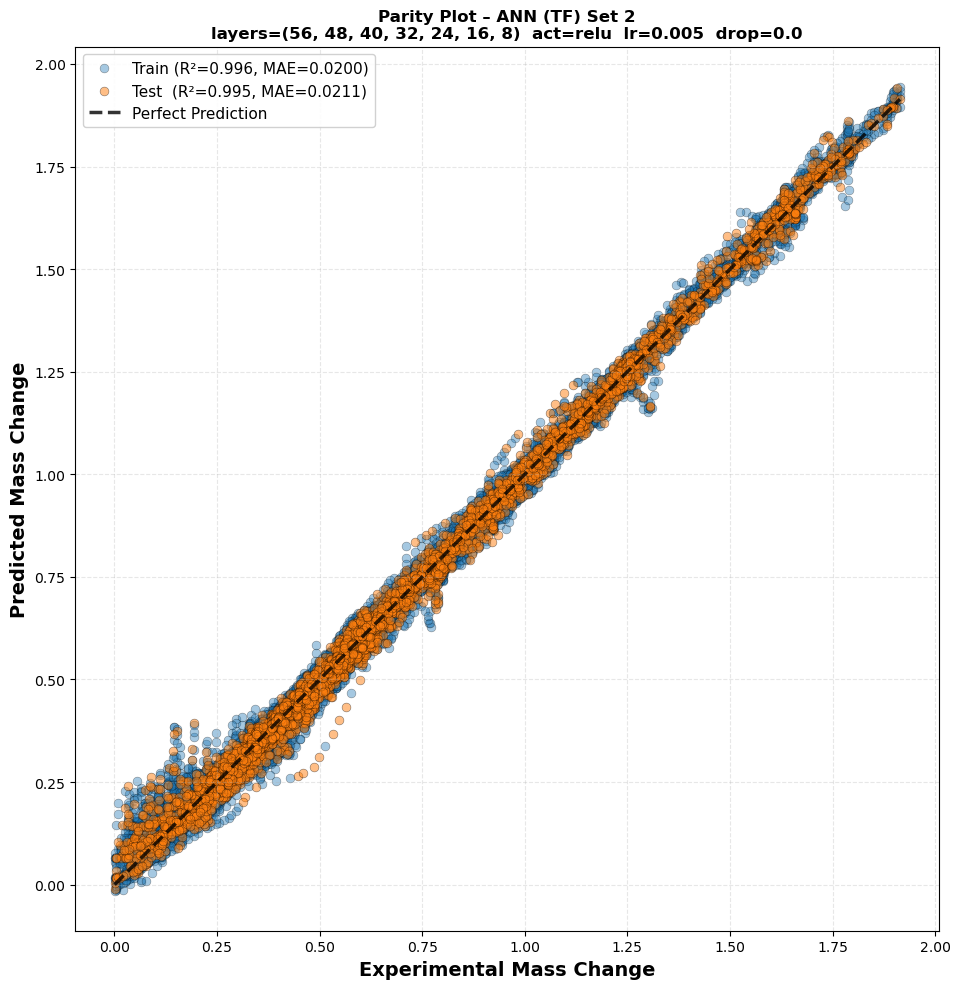

✓ Saved: ann_tf_parity_plots/parity_plot_set02.png


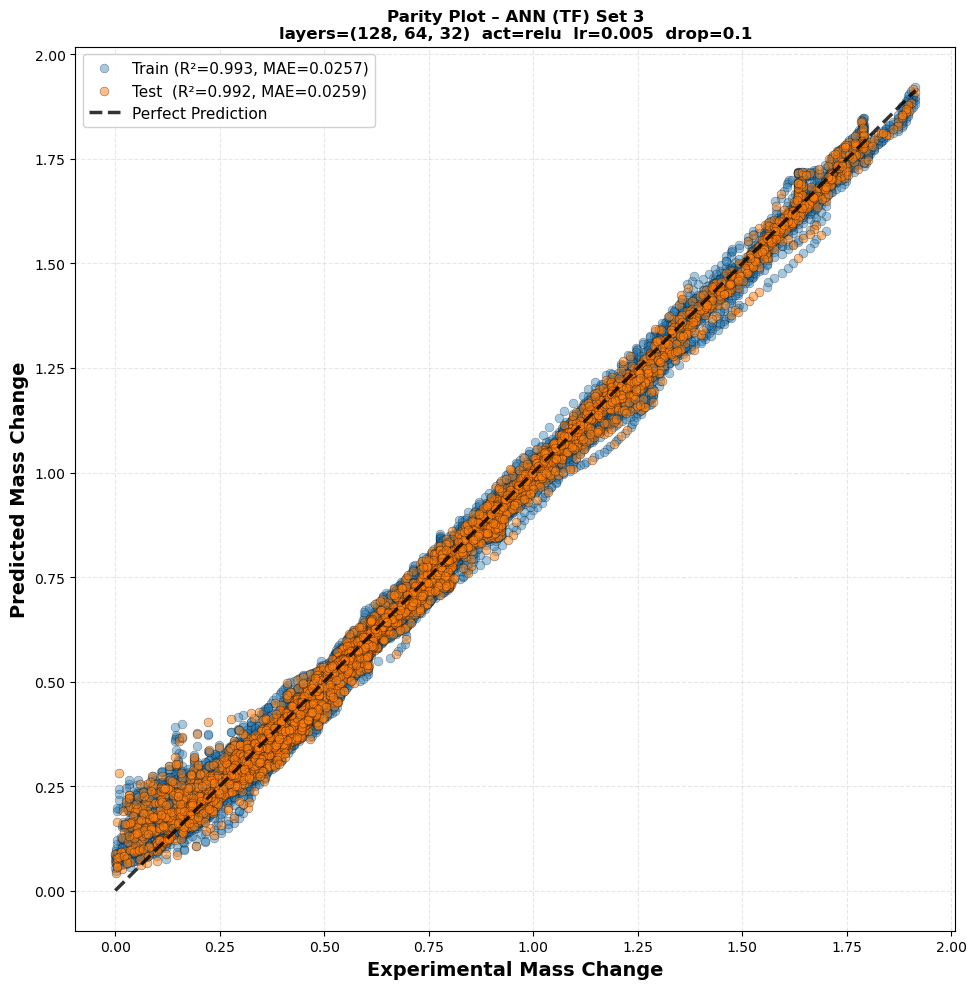

✓ Saved: ann_tf_parity_plots/parity_plot_set03.png


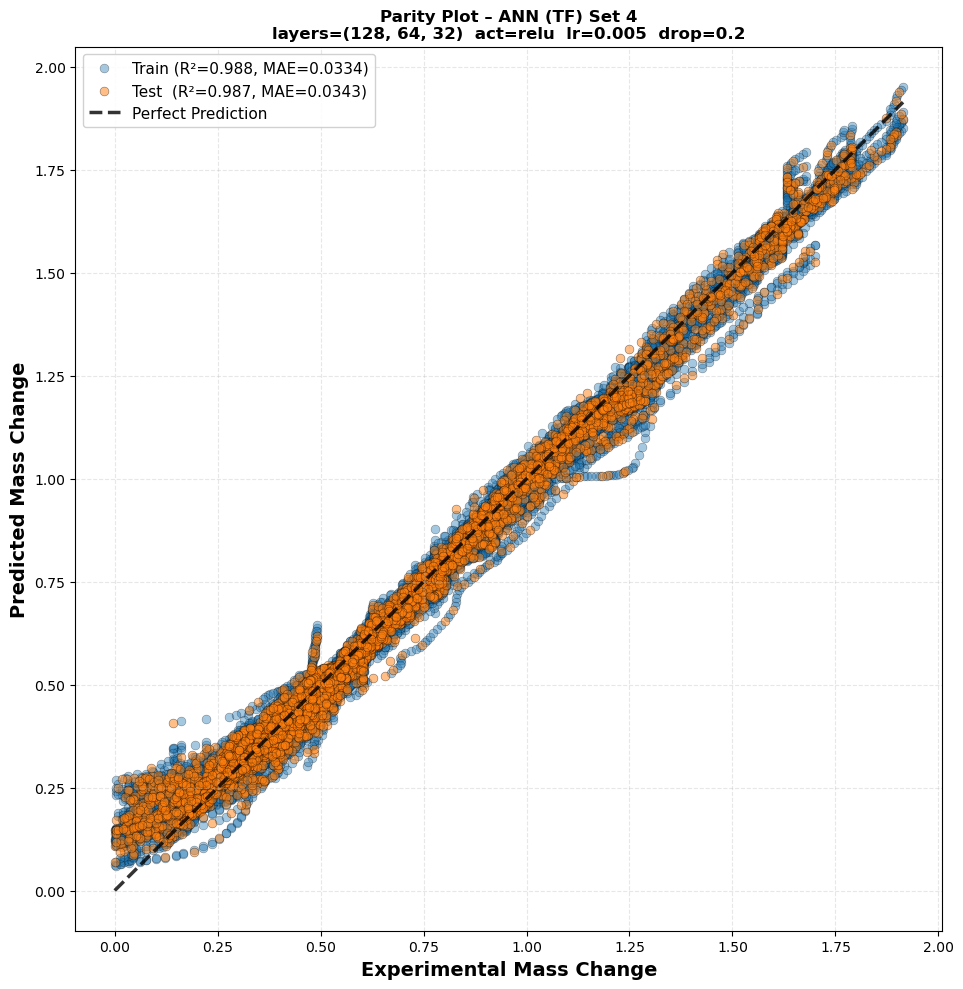

✓ Saved: ann_tf_parity_plots/parity_plot_set04.png


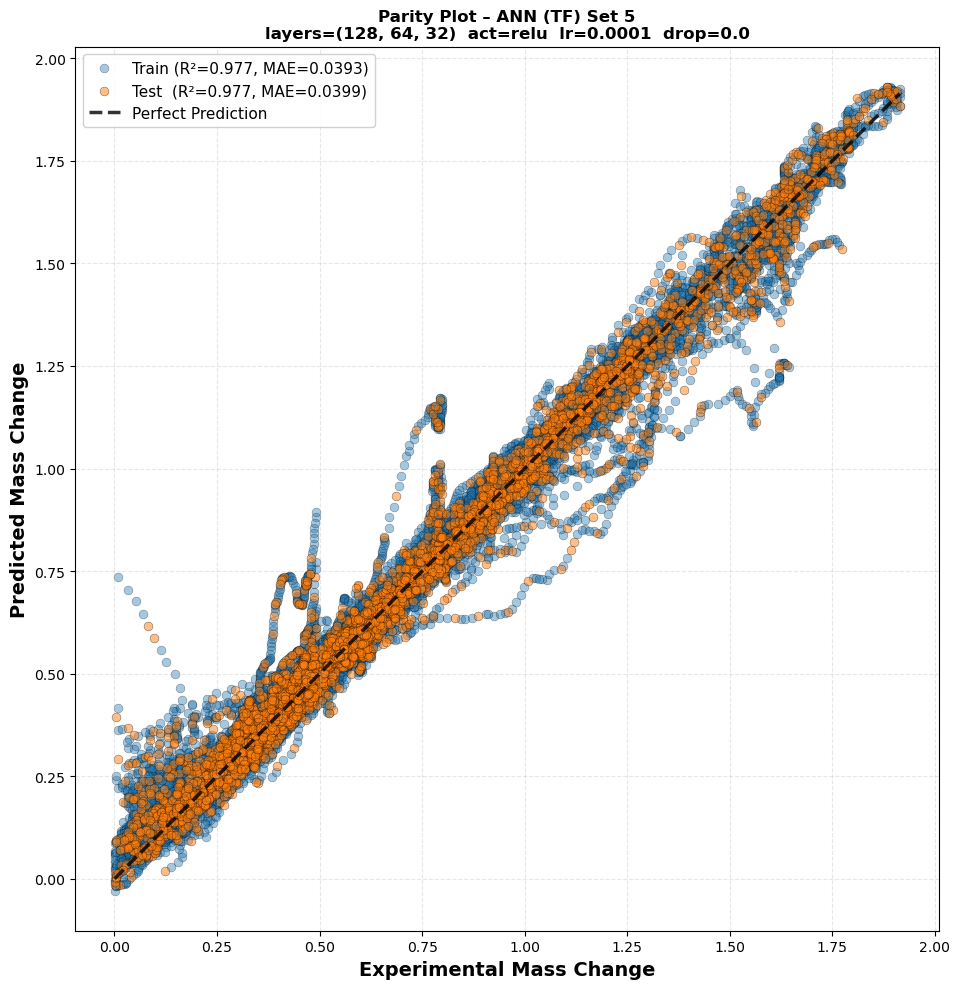

✓ Saved: ann_tf_parity_plots/parity_plot_set05.png

All parity plots generated!


In [23]:
print('=' * 70)
print('GENERATING PARITY PLOTS')
print('=' * 70)

for set_idx in range(1, top_n_sets + 1):
    metrics         = locals()[f'metrics_set{set_idx}']
    all_predictions = locals()[f'predictions_set{set_idx}']
    param_set       = locals()[f'params_set{set_idx}']

    tr_r2  = np.mean(metrics['train_r2'])
    te_r2  = np.mean(metrics['test_r2'])
    tr_mae = np.mean(metrics['train_mae'])
    te_mae = np.mean(metrics['test_mae'])

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(all_predictions['y_train'], all_predictions['train'],
               alpha=0.4, s=40, edgecolors='k', lw=0.4,
               label=f'Train (R²={tr_r2:.3f}, MAE={tr_mae:.4f})')
    ax.scatter(all_predictions['y_test'],  all_predictions['test'],
               alpha=0.5, s=40, edgecolors='k', lw=0.4,
               label=f'Test  (R²={te_r2:.3f}, MAE={te_mae:.4f})')

    y_min, y_max = float(min(Y)), float(max(Y))
    ax.plot([y_min, y_max], [y_min, y_max],
            'k--', lw=2.5, label='Perfect Prediction', alpha=0.8)

    ax.set_xlabel('Experimental Mass Change', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Mass Change',    fontsize=14, fontweight='bold')
    ax.set_title(
        f'Parity Plot – ANN (TF) Set {set_idx}\n'
        f'layers={param_set["hidden_layers"]}  '
        f'act={param_set["activation"]}  '
        f'lr={param_set["learning_rate"]}  '
        f'drop={param_set["dropout_rate"]}',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.savefig(f'{PARITY_DIR}/parity_plot_set{set_idx:02d}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {PARITY_DIR}/parity_plot_set{set_idx:02d}.png')

print('\nAll parity plots generated!')


## Training Loss Curves (Best Set)

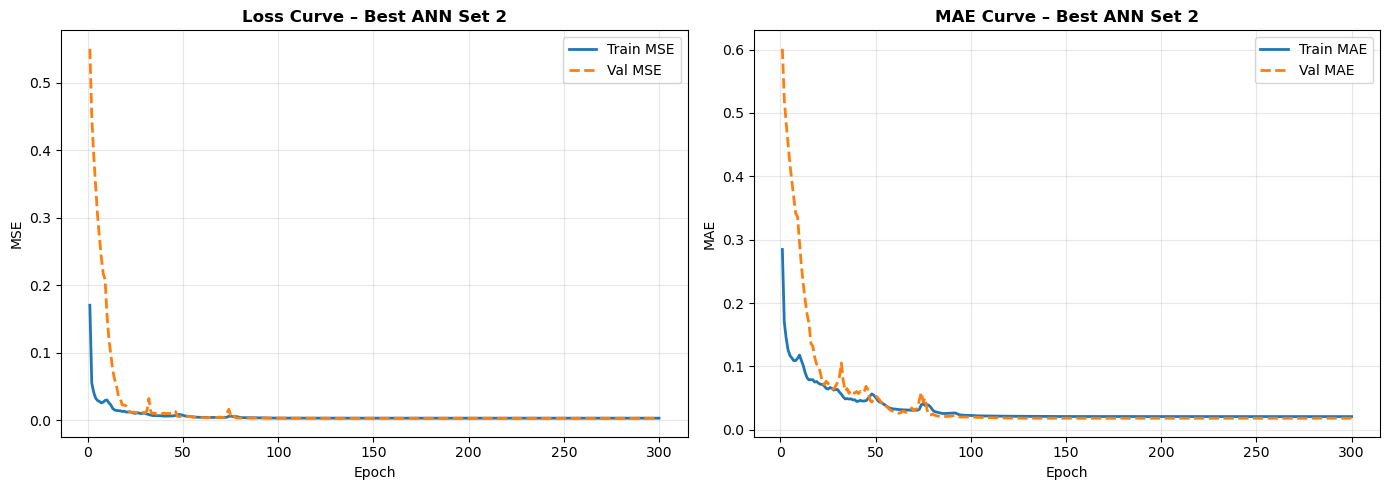

Saved -> ann_tf_results/training_loss_curve.png


In [24]:
# Retrain best set on full data and plot convergence
comparison_df_tmp = pd.DataFrame(all_param_set_results).round(6)
best_set_idx_tmp  = comparison_df_tmp['test_mae_mean'].idxmin() + 1
best_ps           = top_param_sets[best_set_idx_tmp - 1]

scaler_hist = StandardScaler()
X_sc_full   = scaler_hist.fit_transform(X)
val_n       = max(1, int(len(X_sc_full) * VAL_FRACTION))

model_hist = build_keras_model(
    input_dim     = X.shape[1],
    hidden_layers = best_ps['hidden_layers'],
    activation    = best_ps['activation'],
    dropout_rate  = best_ps['dropout_rate'],
    l2_reg        = best_ps['l2_reg'],
    learning_rate = best_ps['learning_rate'],
    batch_norm    = best_ps['batch_norm'],
)

hist = model_hist.fit(
    X_sc_full[:-val_n], Y[:-val_n],
    validation_data=(X_sc_full[-val_n:], Y[-val_n:]),
    epochs=MAX_EPOCHS,
    batch_size=best_ps['batch_size'],
    callbacks=[callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10,
        min_lr=1e-6, verbose=0)],
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(hist.history['loss']) + 1)

axes[0].plot(ep, hist.history['loss'],     label='Train MSE', lw=2)
axes[0].plot(ep, hist.history['val_loss'], label='Val MSE',   lw=2, ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title(f'Loss Curve – Best ANN Set {best_set_idx_tmp}', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, hist.history['mae'],     label='Train MAE', lw=2)
axes[1].plot(ep, hist.history['val_mae'], label='Val MAE',   lw=2, ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].set_title(f'MAE Curve – Best ANN Set {best_set_idx_tmp}', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {RESULTS_DIR}/training_loss_curve.png')
del model_hist; keras.backend.clear_session()


## Comparison of All Parameter Sets

Test Performance Comparison:


,param_set,test_mae_mean,test_rmse_mean,test_r2_mean
0,1,0.028349,0.039374,0.991492
1,2,0.021091,0.030053,0.995036
2,3,0.025937,0.037318,0.992319
3,4,0.034323,0.048183,0.987305
4,5,0.039879,0.060266,0.977417



Saved -> ann_tf_results/all_parameter_sets_comparison.csv


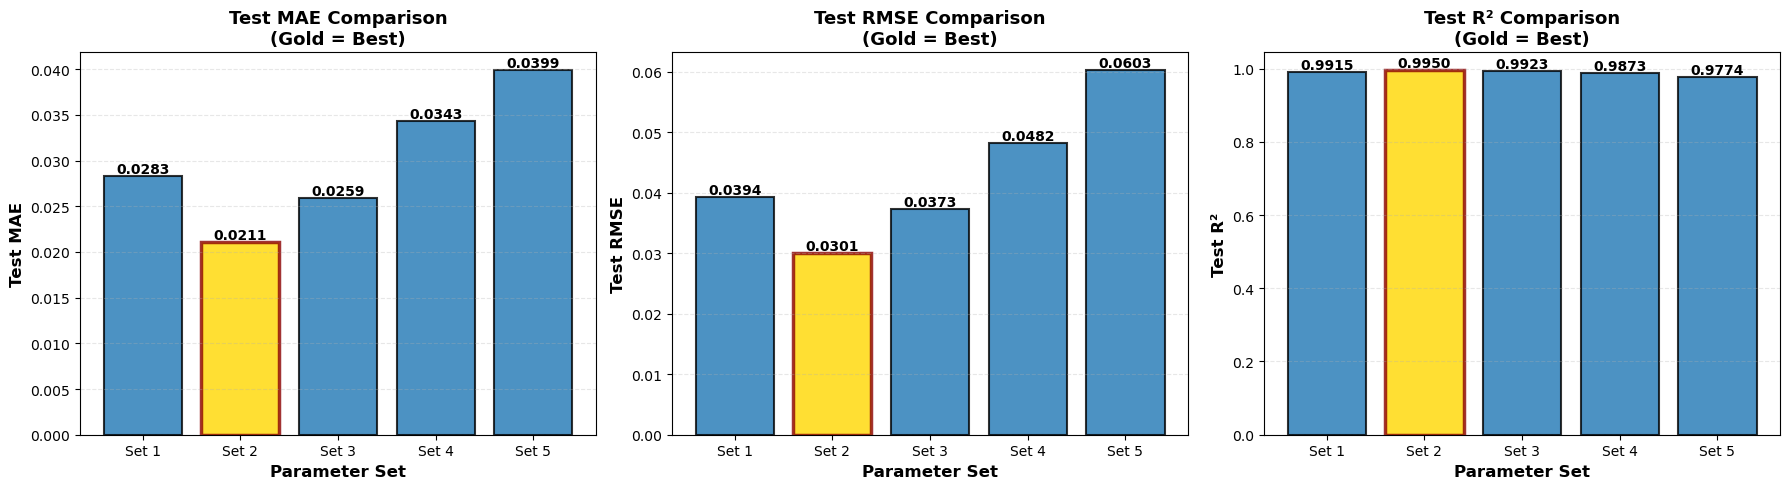

Saved -> ann_tf_results/parameter_sets_comparison.png


In [25]:
comparison_df = pd.DataFrame(all_param_set_results).round(6)
print('Test Performance Comparison:')
display(comparison_df[['param_set','test_mae_mean','test_rmse_mean','test_r2_mean']])
comparison_df.to_csv(f'{RESULTS_DIR}/all_parameter_sets_comparison.csv', index=False)
print(f'\nSaved -> {RESULTS_DIR}/all_parameter_sets_comparison.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (metric, title, better) in enumerate([
        ('test_mae_mean',  'Test MAE',  'lower'),
        ('test_rmse_mean', 'Test RMSE', 'lower'),
        ('test_r2_mean',   'Test R²',   'higher')]):
    x_pos = np.arange(len(comparison_df))
    bars  = axes[idx].bar(x_pos, comparison_df[metric],
                          alpha=0.8, edgecolor='black', linewidth=1.5)
    best_i = (comparison_df[metric].idxmin() if better == 'lower'
              else comparison_df[metric].idxmax())
    bars[best_i].set_color('gold'); bars[best_i].set_edgecolor('darkred'); bars[best_i].set_linewidth(2.5)
    for bar in bars:
        h = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., h,
                       f'{h:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Parameter Set', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(title, fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{title} Comparison\n(Gold = Best)', fontsize=13, fontweight='bold')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels([f'Set {i+1}' for i in range(len(comparison_df))])
    axes[idx].grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/parameter_sets_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {RESULTS_DIR}/parameter_sets_comparison.png')


In [26]:
print('=' * 70)
print('FINAL SUMMARY – ANN (TensorFlow/Keras)')
print('=' * 70)

best_set_idx   = comparison_df['test_mae_mean'].idxmin() + 1
best_param_set = top_param_sets[best_set_idx - 1]
best_row       = comparison_df[comparison_df['param_set'] == best_set_idx].iloc[0]

print(f'\nBest Performing Parameter Set: Set {best_set_idx}')
print('-' * 70)
print('\nArchitecture:')
for k, v in best_param_set.items(): print(f'  {k}: {v}')
print(f'\nPerformance Metrics (5-fold CV):')
print(f'  Test MAE  : {best_row["test_mae_mean"]:.6f} ± {best_row["test_mae_std"]:.6f}')
print(f'  Test RMSE : {best_row["test_rmse_mean"]:.6f} ± {best_row["test_rmse_std"]:.6f}')
print(f'  Test MAPE : {best_row["test_mape_mean"]:.6f} ± {best_row["test_mape_std"]:.6f}')
print(f'  Test R²   : {best_row["test_r2_mean"]:.6f} ± {best_row["test_r2_std"]:.6f}')
print(f'\nDevice   : {DEVICE}')
print(f'TF ver   : {tf.__version__}')

with open(f'{RESULTS_DIR}/FINAL_SUMMARY.txt', 'w') as f:
    f.write('=' * 70 + '\n')
    f.write('ANN TensorFlow/Keras – Final Summary\n')
    f.write('=' * 70 + '\n\n')
    f.write(f'Device: {DEVICE}\n')
    f.write(f'TF version: {tf.__version__}\n')
    f.write(f'\nBest Set: {best_set_idx}\n')
    for k, v in best_param_set.items(): f.write(f'  {k}: {v}\n')
    f.write(f'\nTest MAE  : {best_row["test_mae_mean"]:.6f} ± {best_row["test_mae_std"]:.6f}\n')
    f.write(f'Test RMSE : {best_row["test_rmse_mean"]:.6f} ± {best_row["test_rmse_std"]:.6f}\n')
    f.write(f'Test R²   : {best_row["test_r2_mean"]:.6f} ± {best_row["test_r2_std"]:.6f}\n')
print(f'\nSaved -> {RESULTS_DIR}/FINAL_SUMMARY.txt')


FINAL SUMMARY – ANN (TensorFlow/Keras)

Best Performing Parameter Set: Set 2
----------------------------------------------------------------------

Architecture:
  hidden_layers: (56, 48, 40, 32, 24, 16, 8)
  activation: relu
  dropout_rate: 0.0
  l2_reg: 1e-05
  learning_rate: 0.005
  batch_norm: True
  batch_size: 256

Performance Metrics (5-fold CV):
  Test MAE  : 0.021091 ± 0.001857
  Test RMSE : 0.030053 ± 0.002795
  Test MAPE : 0.105979 ± 0.029087
  Test R²   : 0.995036 ± 0.000905

Device   : /CPU:0
TF ver   : 2.20.0

Saved -> ann_tf_results/FINAL_SUMMARY.txt
